In [1]:
import numpy as np
from matplotlib import pyplot as plt

from loki.libloki.configs import PulsarSearchConfig
from loki.libloki.plans import FFAPlanBase
from loki.libloki.prune import EPMultiPassFourier
from pyloki.config import ParamLimits
from pyloki.detection import thresholding
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


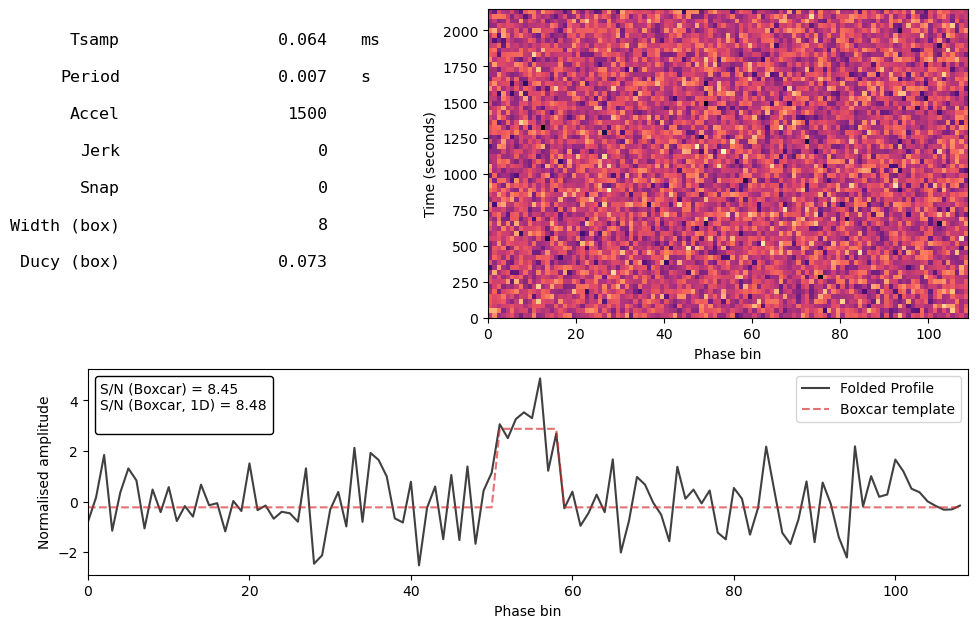

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 1500
nsamps = 2**25
mod_kwargs = {"acc": accel}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=8.5,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_upper((140.0, 150.0), [accel], (-2500.0, 2500.0), cfg.tobs)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 16384
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=2,
    nthreads=8,
    ducy_max=0.5,
    wtsp=1.2,
    use_fourier=True,
)
plan = FFAPlanBase(search_cfg)
branching_pattern = plan.get_branching_pattern()
branching_pattern

Param limits: [[-2500.          2500.        ]
 [  138.74643398   151.34310645]]


array([4.        , 7.44566021, 1.31313673, 1.        , 2.36409419,
       3.80695492, 1.        , 2.36409419, 1.        , 1.26898497,
       1.        , 1.        , 1.        , 1.        , 2.36409419,
       1.        , 1.        , 3.80695492, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       2.36409419, 1.        , 1.        , 1.        , 1.        ,
       1.26898497, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.66748333,
       1.41776182, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.80695492, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

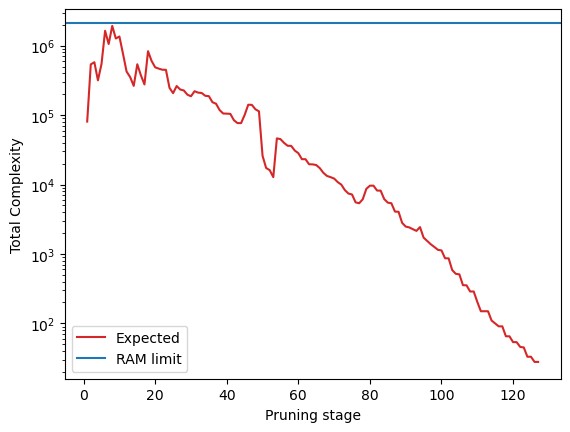

In [4]:
thresholds = np.array([1.9, 2.2, 2.4, 2.8, 2.8, 2.8, 3. , 3. , 3.2, 3.1, 3.4, 3.6, 3.5,
       3.6, 3.5, 3.7, 3.8, 3.8, 3.9, 3.9, 3.7, 3.6, 3.3, 4. , 4. , 4.3,
       4.2, 4. , 4.1, 4. , 4. , 3.9, 3.7, 3.9, 3.7, 4. , 3.9, 4.1, 4.1,
       3.8, 3.7, 4.1, 4.1, 3.7, 4.2, 4. , 3.8, 4.1, 4.1, 4.8, 4.9, 4.8,
       4.9, 4.8, 4.7, 4.8, 4.8, 4.6, 4.8, 4.8, 4.9, 4.6, 4.9, 4.7, 4.7,
       4.8, 4.9, 4.9, 4.8, 4.8, 4.9, 4.9, 5. , 5. , 4.9, 5.1, 5. , 5.1,
       4.9, 5.1, 4.5, 5.1, 4.9, 5.2, 5.2, 5.1, 5.3, 5.1, 5.4, 5.4, 5.3,
       5.3, 5.4, 5.2, 5.5, 5.5, 5.5, 5.5, 5.5, 5.4, 5.6, 5.4, 5.7, 5.7,
       5.6, 5.8, 5.6, 5.8, 5.4, 5.9, 6. , 5.3, 5.3, 6. , 6. , 6. , 5.4,
       6.1, 5.5, 6.1, 5.5, 6.1, 6. , 6.2, 5.5, 6.2, 5.5])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=8.5,
    ducy_max=0.5,
    wtsp=1.2,
)
nparam_vol = plan.ncoords[-1]
x = np.arange(1, len(branching_pattern) + 1)
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**21, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [5]:
prn_manager = EPMultiPassFourier(
    search_cfg,
    thresholds,
    n_runs=32,
    max_sugg=2**21,
    batch_size=1024,
    poly_basis="taylor",
    show_progress=False,
)
prn_manager.execute(
    tim_data.ts_e,
    tim_data.ts_v,
    outdir="pruning_results/accel_test/",
    file_prefix="test_accel",
)

[2026-04-25 11:18:21.854] [info] EPMultiPass: Initializing with FFA
[2026-04-25 11:18:22.031] [info] P-FFA [16384, 1, 53, 2, 33] -> [128, 3, 6763, 2, 33]
[2026-04-25 11:18:22.031] [info] FFA Memory Usage: 2.55 GB + 0.00 GB (coords)
[2026-04-25 11:18:25.155] [info] Starting Pruning for 32 runs, with 8 threads
[2026-04-25 11:18:25.164] [info] Pruning run 022: Memory Usage: 1.17 GB (tree) + 0.02 GB (workspace)
[2026-04-25 11:18:25.165] [info] Pruning run 022: initialized
[2026-04-25 11:18:25.167] [info] Pruning run 018: Memory Usage: 1.17 GB (tree) + 0.02 GB (workspace)
[2026-04-25 11:18:25.168] [info] Pruning run 026: Memory Usage: 1.17 GB (tree) + 0.02 GB (workspace)
[2026-04-25 11:18:25.168] [info] Pruning run 018: initialized
[2026-04-25 11:18:25.169] [info] Pruning run 010: Memory Usage: 1.17 GB (tree) + 0.02 GB (workspace)
[2026-04-25 11:18:25.169] [info] Pruning run 006: Memory Usage: 1.17 GB (tree) + 0.02 GB (workspace)
[2026-04-25 11:18:25.170] [info] Pruning run 026: initialized

In [6]:
result_file = "pruning_results/accel_test/test_accel_pruning_nstages_128_results.h5"
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, score_type="score", run_id=None))

26-04-25 11:18:34.469] [info] Pruning run 022: timer: Total: 9.2s (score: 68% | shift_add: 15% | batch_add: 14% | resolve: 2%)
[2026-04-25 11:18:34.471] [info] Pruning run 046: Memory Usage: 1.17 GB (tree) + 0.02 GB (workspace)
[2026-04-25 11:18:34.471] [info] Pruning run 046: initialized
[2026-04-25 11:18:34.476] [info] Pruning run 014: complete
[2026-04-25 11:18:34.476] [info] Pruning run 014: stats: Score: 6.94, Leaves: 4.86
[2026-04-25 11:18:34.476] [info] Pruning run 014: timer: Total: 9.3s (score: 68% | shift_add: 16% | batch_add: 13% | resolve: 2%)
[2026-04-25 11:18:34.478] [info] Pruning run 050: Memory Usage: 1.17 GB (tree) + 0.02 GB (workspace)
[2026-04-25 11:18:34.479] [info] Pruning run 050: initialized
[2026-04-25 11:18:34.511] [info] Pruning run 030: complete
[2026-04-25 11:18:34.511] [info] Pruning run 030: stats: Score: 6.59, Leaves: 2.58
[2026-04-25 11:18:34.511] [info] Pruning run 030: timer: Total: 9.3s (score: 70% | shift_add: 17% | batch_add: 10% | resolve: 2%)
[20

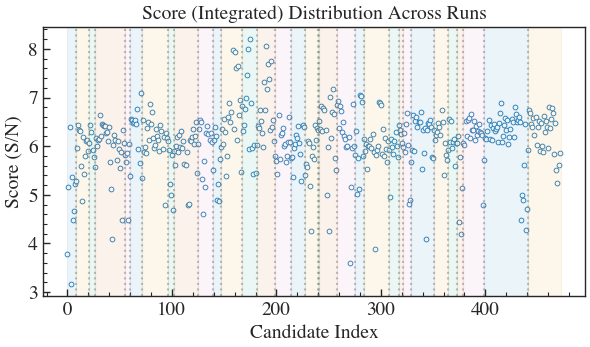

In [7]:
pgram.plot_scores(kind="scatter", run_id=None)
plt.show()

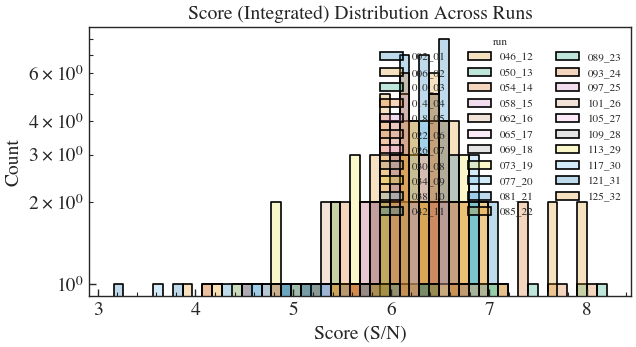

In [8]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

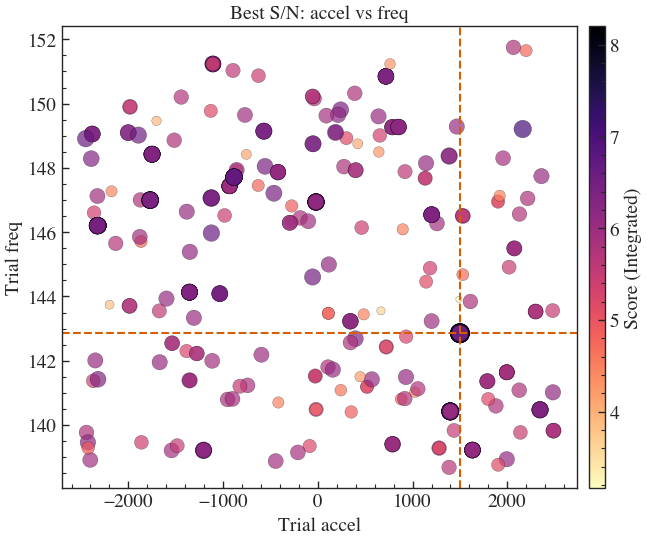

In [9]:
pgram.plot_correlation("accel", "freq", true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq}, run_id=None)
plt.show()

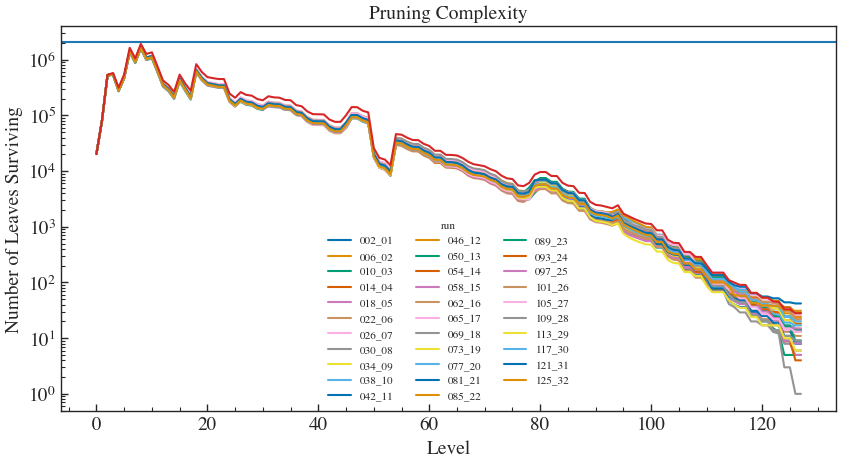

In [10]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(x, np.concatenate(([1], thresh_state.get_info("complexity"))) * nparam_vol, label="Expected", c="tab:red")
ax_list[0].axhline(2**21, label="RAM limit", c="tab:blue")
plt.show()